<a href="https://colab.research.google.com/github/kael-24/MNIST-Exploratory-Data-Analysis/blob/main/MidtermGroupActivityMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part A - DATA PREPARATION

1. Discuss the data

The MNIST dataset is a handwritten digits dataset that consists of greyscale handwritten images of numbers 0-9 from tensorflow. It is primarily used for multiclass classification tasks.

It was created by Yann LeCunn as a benchmark dataset for machine learning models for image classification tasks.

Each image is 28 x 28 in size, and flattened into 784 numerical features.

As instructed, the sample size is limited to a subset of 2000 samples to keep computational constraints at a feasible level while maintaining sufficient data for training and evaluation.

Summary of details:
Total Sample includes 2000 images, Image size is around 28 x 28 pixels,
Features per sample are 784, Classes are 10 with digits being 0-9, and the data type is Numerical with pixel intensities from 0 to 255.


2. Load the data and perform EDA (describe, null check, distributions)

In [ ]:
from tensorflow.keras.datasets import mnist
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data()

X = np.concatenate((x_train_full, x_test), axis = 0)[:2000]
y = np.concatenate((y_train_full, y_test), axis = 0)[:2000]

X = X.reshape(2000, -1)

df = pd.DataFrame(X)
df['label'] = y

print(df.head(), "\n")

print(df.info(), "\n")

print(df.describe(), "\n")

print(df.isnull().sum(), "\n")

   0  1  2  3  4  5  6  7  8  9  ...  775  776  777  778  779  780  781  782  \
0  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
1  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
2  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
3  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
4  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   

   783  label  
0    0      5  
1    0      0  
2    0      4  
3    0      1  
4    0      9  

[5 rows x 785 columns] 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Columns: 785 entries, 0 to label
dtypes: uint8(785)
memory usage: 1.5 MB
None 

            0       1       2       3       4       5       6       7       8  \
count  2000.0  2000.0  2000.0  2000.0  2000.0  2000.0  2000.0  2000.0  2000.0   
mean      0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   


The pixel values range from 0(white) to 255(black) while the mean values are relatively low, implying that most of the image is dark background with the pixels having low variances, which is mostly always black.

The null checking also shows the absence of null values, meaning MNIST is a clean dataset, with minimal preprocessing.

CLASS DISTRIBUTION:
The dataset below is shown to be roughly balanced, with small variation as well as the 7 being the most prominent in count. This shows that the imbalance issue is minimal.

In [ ]:
print(df['label'].value_counts(), "\n")

label
7    224
1    220
4    214
9    210
6    200
2    198
3    191
0    191
5    180
8    172
Name: count, dtype: int64 



PIXEL INTENSITY DISTRIBUTION: The pixel intensity distribution below show the color distribution of pixels among the dataset, where a majority of the pixels on those images are of the background color, as shown by the exceedingly high bar on the 0. The digit strokes being 255 are a mere fraction of the background pixels, using pixels only as necessary.

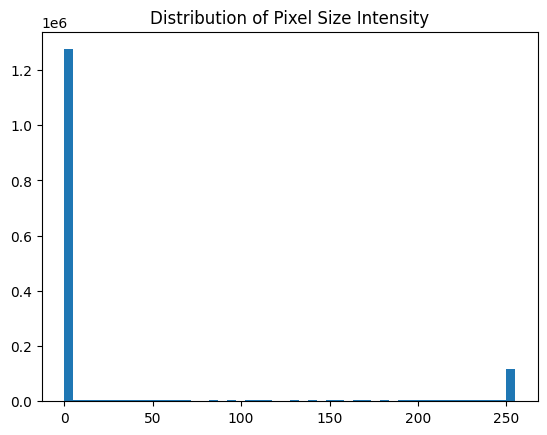

In [ ]:
plt.hist(df.iloc[:,:-1].values.flatten(), bins = 50)
plt.title("Distribution of Pixel Size Intensity")
plt.show()

SAMPLE VISUALIZATION: The figure below shows a sample digit stroke, which proves the prevalence of the black pixels (0) against white pixels (255) as seen with the figure above. The image shown is handwritten, with a unique writing style and thickness.

We used the handritten digit stroke for number 5 as a sample visualization.

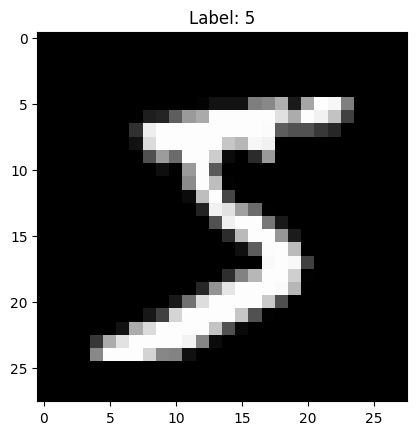

In [ ]:
plt.imshow(X[0].reshape(28,28), cmap = 'gray')
plt.title(f"Label: {y[0]}")
plt.show()

3. Handle missing values with at least 2 different strategies.

A. Mean Imputation

In [ ]:
df = df.fillna(df.mean())

B. Zero Imputation

In [ ]:
df = df.fillna(0)

4. Normalize/Standardize Numerical Features

Normalization: Scales the values to 0 - 1 for efficient training.

In [ ]:
X_norm = X / 255

Standardization: Centers the data around a mean of 0 and a std of 1.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_std = scaler.fit_transform(X)

5. Train / Validation / Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_norm, y, test_size = 0.3, random_state = 42)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size = 0.15, random_state = 42
)



Final Summary of Data Splitting:

Training set = 1400
Test set = 300
Validation set = 300

Part B - MODEL TRAINING

1. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

logReg = LogisticRegression(max_iter=1000)

logReg = logReg.fit(X_train, y_train)

Validation of Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = logReg.predict(X_val)

y_accuracy = accuracy_score(y_val, y_pred)

print(f"The accuracy of the Logistic Regression Model is: {y_accuracy}")

The accuracy of the Logistic Regression Model is: 0.9


The result shows a 90% accuracy from the Logistic Regression Model

2. K-Nearest Neighbors

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

k_values = [1,2,3,4,5,6,7,8,9]
k_accuracy_list = []

for k in k_values:
  knn = KNeighborsClassifier(n_neighbors = k)
  knn.fit(X_train, y_train)

  knn_pred = knn.predict(X_val)
  knn_accuracy =  accuracy_score(y_val, knn_pred)

  k_accuracy_list.append(knn_accuracy)
  print(f"K Nearest Neighbors Accuracy for {k}: {knn_accuracy: .2f} \n")

best_index = k_accuracy_list.index(max(k_accuracy_list))
best_knn = k_values[best_index]
best_accuracy = k_accuracy_list[best_index]

print(f"Highest Accuracy: {best_accuracy: .2f} by the best k that is {best_knn} ")

K Nearest Neighbors Accuracy for 1:  0.89 

K Nearest Neighbors Accuracy for 2:  0.86 

K Nearest Neighbors Accuracy for 3:  0.88 

K Nearest Neighbors Accuracy for 4:  0.90 

K Nearest Neighbors Accuracy for 5:  0.92 

K Nearest Neighbors Accuracy for 6:  0.92 

K Nearest Neighbors Accuracy for 7:  0.92 

K Nearest Neighbors Accuracy for 8:  0.91 

K Nearest Neighbors Accuracy for 9:  0.90 

Highest Accuracy:  0.92 by the best k that is 5 


The results show that the K Nearest Neighbors model is not too sensitive for both high and low k values, with slight change among them, implying consistency of accuracy.

Upon tuning, the best k is 5.

## **3. Decision Tree**
For the Decision Tree model, we need to tune the max_depth hyperparameter. The depth of a decision tree determines how many splits it makes before coming to a conclusion.

A tree that is too shallow might underfit the data (failing to capture important patterns).

A tree that is too deep might overfit the training data (memorizing noise instead of generalizing well to new data).

We will test a range of depths to find the optimal balance for our validation set.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# depth of tree
depth_values = [5, 10, 15, 20, 25, 30, None]
depth_accuracy_list = []

print("Evaluating Decision Tree depths...\n")

for depth in depth_values:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)

    # train the model
    dt.fit(X_train, y_train)

    # predict on the validation set
    dt_pred = dt.predict(X_val)

    # calculate accuracy
    dt_accuracy = accuracy_score(y_val, dt_pred)
    depth_accuracy_list.append(dt_accuracy)

    print(f"Decision Tree Accuracy for max_depth {depth}: {dt_accuracy:.2f}")

# best performing depth
best_index = depth_accuracy_list.index(max(depth_accuracy_list))
best_depth = depth_values[best_index]
best_accuracy = depth_accuracy_list[best_index]

print(f"\nHighest Accuracy: {best_accuracy:.2f} achieved with the best max_depth that is {best_depth}")

Evaluating Decision Tree depths...

Decision Tree Accuracy for max_depth 5: 0.62
Decision Tree Accuracy for max_depth 10: 0.68
Decision Tree Accuracy for max_depth 15: 0.70
Decision Tree Accuracy for max_depth 20: 0.70
Decision Tree Accuracy for max_depth 25: 0.70
Decision Tree Accuracy for max_depth 30: 0.70
Decision Tree Accuracy for max_depth None: 0.70

Highest Accuracy: 0.70 achieved with the best max_depth that is 15


**DECISION TREE RESULTS**

**At max_depth 5, your accuracy is only 62%. At max_depth 10, it climbs to 68%.**

The tree is too simple here. It hasn't been allowed to ask enough questions about the pixels to reliably tell the difference between numbers.

**At max_depth 15, the accuracy hits its peak at 70%.**

This is the point where the tree has extracted the most useful, generalizable patterns it possibly can from the specific training images.

**From depth 20 all the way to None (unlimited depth), the accuracy completely stalls at exactly 70%.**

The tree is continuing to grow deeper and ask more highly specific questions, but those extra questions aren't helping it perform any better on the unseen validation set. It has hit a "ceiling." At this point, the tree is just overfitting rather than learning new, useful rules for identifying digits.

## **4. Random Forest**

For the Random Forest model, we are tasked with tuning the n_estimators hyperparameter. A Random Forest is an ensemble learning method that operates by constructing a multitude of decision trees during training.

The n_estimators parameter defines the number of trees in the forest.

A lower number of trees trains faster but might not capture the full complexity of the data.

A higher number of trees generally improves model performance and makes the predictions more stable (reducing overfitting compared to a single decision tree), but it increases computational cost and training time.

We will evaluate a range of estimator counts to find the point where the accuracy plateaus on our validation set.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# number of trees
estimator_values = [10, 50, 100, 150, 200]
rf_accuracy_list = []

print("Evaluating Random Forest n_estimators...\n")

for n in estimator_values:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)

    # train the model
    rf.fit(X_train, y_train)

    # predict on the validation set
    rf_pred = rf.predict(X_val)

    # calculate accuracy
    rf_accuracy = accuracy_score(y_val, rf_pred)
    rf_accuracy_list.append(rf_accuracy)

    print(f"Random Forest Accuracy for n_estimators={n}: {rf_accuracy:.4f}")

# best performing n_estimators value
best_rf_index = rf_accuracy_list.index(max(rf_accuracy_list))
best_n_estimators = estimator_values[best_rf_index]
best_rf_accuracy = rf_accuracy_list[best_rf_index]

print(f"\nHighest Accuracy: {best_rf_accuracy:.4f} achieved with {best_n_estimators} estimators.")

Evaluating Random Forest n_estimators...

Random Forest Accuracy for n_estimators=10: 0.8444
Random Forest Accuracy for n_estimators=50: 0.9444
Random Forest Accuracy for n_estimators=100: 0.9556
Random Forest Accuracy for n_estimators=150: 0.9667
Random Forest Accuracy for n_estimators=200: 0.9667

Highest Accuracy: 0.9667 achieved with 150 estimators.


**RANDOM FOREST RESULTS:**

The results show the effect of increasing the number of trees in the forest. Typically, we see a significant jump in accuracy when moving from a very small number of trees (e.g., 10 which has an accuracy of 84.44%) to a moderate number (e.g., 100 which has an accuracy of 95.56%). After a certain point, adding more trees yields diminishing returns, where the accuracy increases while the computational time continues to increase.

Upon tuning, the optimal n_estimators for this subset of the MNIST dataset is **150 with an accuracy of 96.67%**, as it provides the highest accuracy without unnecessary computational overhead.

## **5. SVM with RBF kernel**

For the Support Vector Machine (SVM) model, we are using the Radial Basis Function (RBF) kernel. SVM works by finding the optimal hyperplane (or set of hyperplanes) that separates our digit classes. The RBF kernel is particularly powerful because it allows the SVM to handle non-linear relationships by effectively projecting the pixel data into a higher-dimensional space.

To optimize this model, we will tune the C parameter (the regularization parameter).

A low C value encourages a smoother decision boundary (more regularization), which is simpler but might underfit the data.

A high C value penalizes misclassifications strictly, aiming to classify all training examples correctly. This can lead to a highly complex boundary and potential overfitting.

We will evaluate a logarithmic scale of C values to find the best balance for our validation set.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# C values (regularization parameter) to test
c_values = [0.1, 1, 10, 100]
svm_accuracy_list = []

print("Evaluating SVM with RBF kernel for different C values...\n")

for c in c_values:
    svm = SVC(kernel='rbf', C=c, random_state=42)

    # train the model
    svm.fit(X_train, y_train)

    # predict on the validation set
    svm_pred = svm.predict(X_val)

    # calculate accuracy
    svm_accuracy = accuracy_score(y_val, svm_pred)
    svm_accuracy_list.append(svm_accuracy)

    print(f"SVM (RBF) Accuracy for C={c}: {svm_accuracy:.4f}")

# best performing C value
best_svm_index = svm_accuracy_list.index(max(svm_accuracy_list))
best_c = c_values[best_svm_index]
best_svm_accuracy = svm_accuracy_list[best_svm_index]

print(f"\nHighest Accuracy: {best_svm_accuracy:.4f} achieved with C={best_c}.")

Evaluating SVM with RBF kernel for different C values...

SVM (RBF) Accuracy for C=0.1: 0.8222
SVM (RBF) Accuracy for C=1: 0.9556
SVM (RBF) Accuracy for C=10: 0.9444
SVM (RBF) Accuracy for C=100: 0.9444

Highest Accuracy: 0.9556 achieved with C=1.


**SVM RESULTS:**

The results illustrate the bias-variance tradeoff controlled by the C parameter. A very low C (*like 0.1 which has an accuracy of 82.22%*) often results in lower accuracy because the model is too constrained and underfits the complex pixel relationships of handwritten digits.

As C increases, the model is allowed to fit the training data more closely, typically improving validation accuracy. However, making C extremely large can cause the model to overfit, which might cause the validation accuracy to drop.

Upon tuning, the optimal C parameter for this subset of the MNIST dataset is **1 with the accuracy of 95.56%**, providing the best generalization to unseen validation data.

## **6. Naïve Bayes**

For the Naïve Bayes model, we will be using Gaussian Naïve Bayes (GaussianNB). This variant is well-suited for continuous numerical data, such as our normalized pixel intensities.

Naïve Bayes is based on applying Bayes' theorem with a "naïve" assumption: it assumes that all features (in our case, the 784 pixels) are completely independent of each other given the class label. Unlike Decision Trees, Random Forests, or KNN, a standard Gaussian Naïve Bayes model does not have major hyperparameters that require extensive tuning. It simply calculates the mean and variance of the pixels for each digit class to make its predictions.

Because it requires no tuning and involves simple probability calculations, it is extremely fast to train, though its strong independence assumptions might affect its accuracy on complex image data.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

print("Evaluating Gaussian Naïve Bayes...\n")

# initialize the Gaussian Naïve Bayes model
nb = GaussianNB()

# train the model
nb.fit(X_train, y_train)

# predict on the validation set
nb_pred = nb.predict(X_val)

# calculate accuracy
nb_accuracy = accuracy_score(y_val, nb_pred)

print(f"Gaussian Naïve Bayes Accuracy: {nb_accuracy:.4f}")

Evaluating Gaussian Naïve Bayes...

Gaussian Naïve Bayes Accuracy: 0.6333


**NAÏVE BAYES RESULTS:**

The results show the baseline performance of the Gaussian Naïve Bayes model. Because Naïve Bayes assumes that every pixel is independent of every other pixel, it often struggles slightly with image data like MNIST, where neighboring pixels are highly correlated (forming the continuous strokes of a handwritten digit).

Despite this "naïve" assumption, it usually provides a surprisingly decent baseline accuracy and trains almost instantaneously compared to the SVM or Random Forest models. The accuracy for this model on our validation set is **63.33%**.